## Agentic RAG with LangGraph

In [1]:
import os
from typing import  Dict , TypedDict , List
from langgraph.graph import StateGraph , END
from langchain_groq import ChatGroq
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

c:\Desktop\RAG-Krish Nayak\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
groq_api_key = os.environ["GROQ_API_KEY"]="" #Enter GROQ_API_KEY

print(groq_api_key)

In [3]:
llm = ChatGroq(
    groq_api_key = groq_api_key ,
    model_name ="openai/gpt-oss-20b",
    temperature=0.1,
    max_tokens=1024
)

## State Definition

In [4]:
class AgentState(TypedDict):
    question : str
    documents : List[Document]
    answer : str
    needs_retrieval : bool

In [5]:
# Sample documents and vectorStore

sample_texts = [
    "LangGraph is a framework used to design, build, and manage stateful, multi-step AI agent workflows where large language models can reason, make decisions, use tools, and iterate through tasks in a structured graph-based architecture.",
    "Retrieval-Augmented Generation (RAG) is a technique that enhances the performance of large language models by combining information retrieval with text generation. Instead of relying only on the model's pre-trained knowledge, RAG retrieves relevant information from an external knowledge source such as documents, databases, or APIs and then uses that information to generate more accurate and context-aware responses.",
    "A Vector Database is a specialized database designed to store, index, and retrieve vector embeddings, which are numerical representations of data such as text, images, audio, or video. These embeddings capture the semantic meaning of data, enabling similarity-based search instead of traditional keyword matching.",
    "An Agentic System is an artificial intelligence architecture in which an AI agent can autonomously reason, plan, make decisions, and take actions to complete a task. Unlike traditional LLM pipelines that generate responses in a single step, an agentic system operates through iterative reasoning and tool usage.",
]

documents = [Document(page_content=text) for text in sample_texts]

# creating a Vector Store

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(documents, embeddings)
retriever = vectorstore.as_retriever(k=3)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7924.09it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Agent Function

In [6]:
def decide_retrievel(state: AgentState)-> AgentState:
    """_summary_

    Args:
        state (AgentState):Decide if we need to retrieve documents based on the question
    """
    
    question = state['question'] 
    
    # simple heuristic : if question contains certain keywords , retrieve
    
    retrieval_keywords = ["what"  , "how" , "explain" , "describe" , "tell me"]
    needs_retrieval = any(keyword in question.lower() for keyword in retrieval_keywords)
    
    return {**state , "needs_retrieval" : needs_retrieval}
    

In [7]:
def retrieve_documents(state : AgentState) -> AgentState:
    """
    Retrieve relevent documents based on the question
    
    """
    question = state['question']
    documents = retriever.invoke(question)
    
    return {** state , "documents" : documents}

In [8]:
def generate_answer(state : AgentState) -> AgentState:
    """
    generate an answer using the retrieved documents or direct response
    
    """
    question = state['question']
    documents = state.get("documents" ,[])
    
    if documents:
        # RAG Approach : use documents as context
        
        context = "\n\n".join([doc.page_content for doc in documents])
        prompt = f"""Based on the following context , answer the question:
Context:
{context}    

Question : {question}

Answer: """

    else :
        # Direct response without retrievel
        prompt = f"Answer the following question: {question}"
        
    response = llm.invoke(prompt)
    answer = response.content
    
    return {** state , "answer" : answer}
    

## Conditional logic

In [9]:
def should_retrieve(state : AgentState) -> AgentState:
    """
    Determine the next step based on retrievel decision
    
    """
    
    if state["needs_retrieval"]:
        return "retrieve"
    
    else:
        return "generate"

## Build the Graph

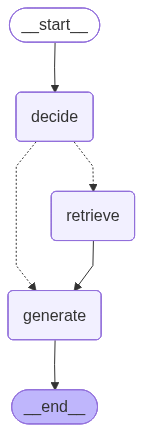

In [10]:
workflow = StateGraph(AgentState)


# Add Nodes

workflow.add_node("decide" , decide_retrievel)
workflow.add_node("retrieve" , retrieve_documents)
workflow.add_node("generate" , generate_answer)

# set entry point 

workflow . set_entry_point("decide")

# Add conditional edge

workflow.add_conditional_edges(
    'decide' , 
    should_retrieve,
    {
        "retrieve" : "retrieve",
        "generate" : 'generate'
    }
)

# Add edges

workflow.add_edge("retrieve" , "generate")
workflow.add_edge("generate" , END)


# Compile the Graph

app = workflow.compile()
app

## Test the Agentic System


In [11]:
def ask_question(question:str):
    """
    Helper function to ask a question and get an answer
    
    """
    
    initial_state = {
        "question" : question,
        "documents" : [],
        "answer" : "",
        "needs_retrieval" : False
    }
    
    result = app.invoke(initial_state)
    return result 

In [13]:
question1 = "What is LangGraph ?" 
result1 = ask_question(question1)
result1

{'question': 'What is LangGraph ?',
 'documents': [Document(id='ef4df519-393c-41fb-90f9-4da839739438', metadata={}, page_content='LangGraph is a framework used to design, build, and manage stateful, multi-step AI agent workflows where large language models can reason, make decisions, use tools, and iterate through tasks in a structured graph-based architecture.'),
  Document(id='040dcee7-e1d0-4e7d-935a-799ff04c2b6e', metadata={}, page_content="Retrieval-Augmented Generation (RAG) is a technique that enhances the performance of large language models by combining information retrieval with text generation. Instead of relying only on the model's pre-trained knowledge, RAG retrieves relevant information from an external knowledge source such as documents, databases, or APIs and then uses that information to generate more accurate and context-aware responses."),
  Document(id='0280997c-2f1c-4b77-ab11-9c1186a5e705', metadata={}, page_content='A Vector Database is a specialized database desig

In [16]:
question2 = "What does RAG work ?"
result2 = ask_question(question2)


print(f"Question : {question2}")
print(f"Retrieved documents : {len(result2['documents'])}")
print(f"Answer : {result2['answer']}")
print("\n" + "=" *50 + "\n")

Question : What does RAG work ?
Retrieved documents : 4
Answer : RAG works by **combining two steps**:

1. **Retrieval** – The system queries an external knowledge source (e.g., a document collection, database, or API) to fetch the most relevant pieces of information for the user’s query.  
2. **Generation** – The retrieved snippets are fed into a large language model, which uses them as context to produce a response that is more accurate, up‑to‑date, and context‑aware than a model that relies only on its pre‑trained knowledge.

In short, RAG augments the language model’s generation with real‑time, external data, enabling it to answer questions with higher precision and relevance.


